# Obesity ML pipeline — visualization (COMP315)

End-to-end **MLOps** artifacts from the **TFX** pipeline (see `obesity_tfx/tfx_pipeline.py`), orchestrated by **Airflow** (`airflow_dags/obesity_dag.py`). This notebook **inspects and visualizes** what each stage produced — it does not re-train the model.

| Pipeline step | Component | Covered here |
|---|---|---|
| 1 | `CsvExampleGen` | Step 1 — train/eval TFRecord paths |
| 2 | `StatisticsGen` | Step 2 — TFDV train vs eval stats |
| 3 | `SchemaGen` | Step 3 — inferred schema |
| 4 | `ExampleValidator` | Step 4 — anomalies vs schema |
| 5 | `Transform` (TFT) | Step 5 — post-transform statistics |
| 6 | `Trainer` | **Step 6** — SavedModel (`Format-Serving`) |
| 8 | `Evaluator` (TFMA) | Step 8 — slicing metrics, fairness, and run comparison |
| 9 | `Pusher` | **Step 9** — blessed model push path |

**Prerequisite:** run the **`obesity_ml_pipeline`** DAG so artifacts exist under `tfx_airflow_runs/outputs/` (or the Airflow copy under `.../dags/COMP315_Group8_project/`).

**Environment:** **`tfx-env`** kernel (`tensorflow-model-analysis`, `tensorflow-data-validation`, `tfx`).

In [2]:
import pathlib
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

import tensorflow_data_validation as tfdv
import tensorflow_model_analysis as tfma

# --- locate pipeline outputs (Airflow deployment or local repo clone) ---
def find_outputs_dir():
    roots = [
        pathlib.Path("/root/airflow/dags/COMP315_Group8_project/tfx_airflow_runs/outputs"),
        pathlib.Path.cwd() / "tfx_airflow_runs" / "outputs",
        pathlib.Path.cwd().parent / "tfx_airflow_runs" / "outputs",
    ]
    for r in roots:
        r = r.resolve()
        if r.is_dir():
            return r
    raise FileNotFoundError(
        "No pipeline outputs found. Run the DAG first, or open the notebook from the repo / set path manually."
    )


def latest_version_dir(component_rel: str) -> pathlib.Path:
    """e.g. component_rel='StatisticsGen/statistics' -> .../statistics/<max_id>"""
    base = OUTPUTS / component_rel
    if not base.is_dir():
        raise FileNotFoundError(base)
    ids = [int(p.name) for p in base.iterdir() if p.is_dir() and p.name.isdigit()]
    if not ids:
        raise FileNotFoundError(f"No version dirs under {base}")
    return base / str(max(ids))


OUTPUTS = find_outputs_dir()
print("Using pipeline outputs:", OUTPUTS)

Using pipeline outputs: /root/airflow/dags/COMP315_Group8_project/tfx_airflow_runs/outputs


## Step 1 — ExampleGen (artifact locations)

Train / eval TFRecord shards produced by `CsvExampleGen` (hash split 2:1).

In [3]:
eg = latest_version_dir("CsvExampleGen/examples")
train_uri = eg / "Split-train"
eval_uri = eg / "Split-eval"
print("ExampleGen version:", eg.name)
print("Train URI:", train_uri)
print("Eval URI:", eval_uri)
for name, u in [("train", train_uri), ("eval", eval_uri)]:
    if u.is_dir():
        n = len(list(u.glob("*")))
        print(f"  {name} shard files (~{n})")

ExampleGen version: 35
Train URI: /root/airflow/dags/COMP315_Group8_project/tfx_airflow_runs/outputs/CsvExampleGen/examples/35/Split-train
Eval URI: /root/airflow/dags/COMP315_Group8_project/tfx_airflow_runs/outputs/CsvExampleGen/examples/35/Split-eval
  train shard files (~1)
  eval shard files (~1)


## Step 2 — StatisticsGen (TFDV)

Interactive comparison of **train** vs **eval** feature statistics.

In [4]:
# StatisticsGen writes binary DatasetFeatureStatisticsList at Split-*/FeatureStats.pb
# (tfdv.load_statistics() expects a TFRecord or text proto file, not a directory.)
stats_root = latest_version_dir("StatisticsGen/statistics")
train_stats = tfdv.load_stats_binary(str(stats_root / "Split-train" / "FeatureStats.pb"))
eval_stats = tfdv.load_stats_binary(str(stats_root / "Split-eval" / "FeatureStats.pb"))
# TFDV 1.x: two protos + labels (dict API is newer only).
tfdv.visualize_statistics(
    train_stats, eval_stats, lhs_name="train", rhs_name="eval"
)

## Step 3 — SchemaGen (TFDV)

Inferred schema from training data.

In [5]:
schema_dir = latest_version_dir("SchemaGen/schema")
schema_path = schema_dir / "schema.pbtxt"
schema = tfdv.load_schema_text(str(schema_path))
tfdv.display_schema(schema)

,Type,Presence,Valency,Domain
Feature name,,,,
'Age',INT,required,,-
'CAEC',STRING,required,,'CAEC'
'CALC',STRING,required,,'CALC'
'CH2O',FLOAT,required,,-
'FAF',FLOAT,required,,-
'FAVC',STRING,required,,'FAVC'
'FCVC',FLOAT,required,,-
'Gender',STRING,required,,'Gender'
'Height',FLOAT,required,,-


,Values
Domain,
'CAEC',"'Always', 'Frequently', 'Sometimes', 'no'"
'CALC',"'Always', 'Frequently', 'Sometimes', 'no'"
'FAVC',"'no', 'yes'"
'Gender',"'Female', 'Male'"
'MTRANS',"'Automobile', 'Bike', 'Motorbike', 'Public_Transportation', 'Walking'"
'NObeyesdad',"'Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II'"
'SCC',"'no', 'yes'"
'SMOKE',"'no', 'yes'"
'family_history_with_overweight',"'no', 'yes'"


## Step 4 — ExampleValidator (TFDV)

Load anomaly artifacts per split (binary `SchemaDiff.pb` -> `Anomalies`), render anomaly details, and plot a per-split anomaly count chart for quick validation reporting.

=== Split-train ===


Anomaly count: 0

=== Split-eval ===


Anomaly count: 0



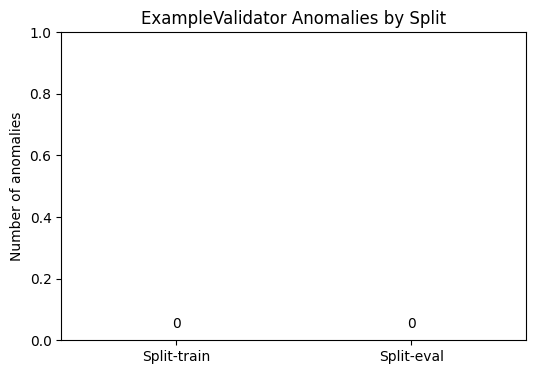

In [6]:
from tensorflow_data_validation.utils.anomalies_util import load_anomalies_binary
from tensorflow_data_validation.utils.display_util import display_anomalies
import matplotlib.pyplot as plt

val_root = latest_version_dir("ExampleValidator/anomalies")
splits = ("Split-train", "Split-eval")
anomaly_counts = {}

for split in splits:
    p = val_root / split / "SchemaDiff.pb"
    if not p.is_file():
        print(split, ": no SchemaDiff.pb")
        anomaly_counts[split] = 0
        continue

    anom = load_anomalies_binary(str(p))
    count = len(anom.anomaly_info)
    anomaly_counts[split] = count

    print("===", split, "===")
    display_anomalies(anom)
    print(f"Anomaly count: {count}\n")

# Visual summary chart for validation report
plt.figure(figsize=(6, 4))
labels = list(anomaly_counts.keys())
values = [anomaly_counts[s] for s in labels]
colors = ["#2ca02c" if v == 0 else "#d62728" for v in values]
bars = plt.bar(labels, values, color=colors)

plt.title("ExampleValidator Anomalies by Split")
plt.ylabel("Number of anomalies")
plt.ylim(0, max(1, max(values) + 1) if values else 1)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03, str(val), ha="center", va="bottom")

plt.show()

## Step 5 — Transform (post-transform statistics)

Distribution of **transformed** features (after TFT `preprocessing_fn`).

In [38]:
post_dir = latest_version_dir("Transform/post_transform_stats")
post_stats = tfdv.load_stats_binary(str(post_dir / "FeatureStats.pb"))
tfdv.visualize_statistics(post_stats)

## Step 6 — Trainer (SavedModel)

Keras **SavedModel** produced by `obesity_tfx/trainer.py` (TFX `Trainer`). The servable lives under **`Format-Serving`** — same graph TFMA evaluates and `Pusher` can deploy when the model is **blessed**.

In [7]:
trainer_run = latest_version_dir("Trainer/model")
saved_model_dir = trainer_run / "Format-Serving"
print("Trainer artifact id:", trainer_run.name)
print("SavedModel (Format-Serving):", saved_model_dir.resolve())
if not saved_model_dir.is_dir():
    print("(Format-Serving not found yet — run the pipeline through Trainer.)")

Trainer artifact id: 40
SavedModel (Format-Serving): /root/airflow/dags/COMP315_Group8_project/tfx_airflow_runs/outputs/Trainer/model/40/Format-Serving


## Step 8 — Evaluator (TFMA notebook views)

### Step 1: Load and render TFMA slicing metrics
Use `tfma.load_eval_result()` and `tfma.view.render_slicing_metrics()` to render the interactive slicing metrics viewer.

### Step 2: Inspect fairness metrics
Use `tfma.view.render_fairness_indicator()` on the same loaded eval result.

### Step 3: Compare two runs
Load two evaluation runs and pass them as a list to `tfma.view.render_slicing_metrics()` for side-by-side comparison.

In [13]:
# Step 1: load eval result and render TFMA slicing metrics
_eval_base = OUTPUTS / "Evaluator" / "evaluation"
_ev_ids = sorted(int(p.name) for p in _eval_base.iterdir() if p.is_dir() and p.name.isdigit())
if not _ev_ids:
    raise FileNotFoundError(_eval_base)

eval_dirs = [_eval_base / str(i) for i in _ev_ids]
eval_dir = eval_dirs[-1]
print("TFMA evaluation directory (latest):", eval_dir)

eval_result = tfma.load_eval_result(str(eval_dir))
tfma.view.render_slicing_metrics(eval_result)


def _slice_label(slice_key):
    if not slice_key:
        return "Overall"
    return ", ".join(f"{k}={v}" for k, v in slice_key)


def _metric_value(metrics_map, metric_name):
    # TFMA 0.43 metrics are nested like metrics[''][''][metric]['doubleValue'].
    node = metrics_map
    while isinstance(node, dict) and "" in node:
        node = node[""]
    if isinstance(node, dict) and metric_name in node:
        metric_node = node[metric_name]
        if isinstance(metric_node, dict) and "doubleValue" in metric_node:
            return metric_node["doubleValue"]
    return None


def _print_metrics_table(result, title):
    print(f"\n{title}")
    print("slice | binary_accuracy | auc")
    print("-" * 45)
    for slice_key, metrics_map in result.slicing_metrics:
        acc = _metric_value(metrics_map, "binary_accuracy")
        auc = _metric_value(metrics_map, "auc")
        if acc is None and auc is None:
            continue
        print(f"{_slice_label(slice_key)} | {acc} | {auc}")


# Fallback output when interactive windows are not visible
_print_metrics_table(eval_result, "Step 1 fallback metrics table:")

print("\nStep 1 summary guide:")
print("- Compare AUC and BinaryAccuracy across Overall and each EvalConfig slice.")
print("- Record the lowest-performing slice.")

TFMA evaluation directory (latest): /root/airflow/dags/COMP315_Group8_project/tfx_airflow_runs/outputs/Evaluator/evaluation/49

Step 1 fallback metrics table:
slice | binary_accuracy | auc
---------------------------------------------
Age_bucket=3 | 0.6 | 0.492453231292517
Overall | 0.5821917808219178 | 0.506566777654458
Gender=1 | 0.6132596685082873 | 0.5224330900243309
Age_bucket=2 | 0.6331360946745562 | 0.5125744047619049
Gender=0 | 0.5516304347826086 | 0.5171567898664923
Age_bucket=1 | 0.5306122448979592 | 0.518773466833542
Age_bucket=0 | 0.4074074074074074 | 0.4141483516483516
Age_bucket=5 | 0.5454545454545454 | 0.4243943191311612
Age_bucket=4 | 0.6235294117647059 | 0.563280241067585

Step 1 summary guide:
- Compare AUC and BinaryAccuracy across Overall and each EvalConfig slice.
- Record the lowest-performing slice.


In [15]:
# Step 2: inspect fairness metrics
# Use getattr to avoid static-checker errors when attribute is absent in tfma.view.
render_fairness = getattr(tfma.view, "render_fairness_indicator", None)
if callable(render_fairness):
    render_fairness(eval_result)
else:
    from tensorflow_model_analysis.addons.fairness.view import widget_view as fairness_widget_view
    fairness_widget_view.render_fairness_indicator(eval_result)

print("\nStep 2 analysis guide:")
print("- Identify the slice with the weakest fairness/performance metrics.")
print("- Note likely causes (class imbalance, noisy labels, low sample count).")
print("- Propose one fix (targeted collection, balancing, preprocessing cleanup).")


Step 2 analysis guide:
- Identify the slice with the weakest fairness/performance metrics.
- Note likely causes (class imbalance, noisy labels, low sample count).
- Propose one fix (targeted collection, balancing, preprocessing cleanup).


In [16]:
# Step 3: compare two runs
if len(eval_dirs) < 2:
    print("Need at least two Evaluator runs for comparison. Re-run pipeline once more.")
else:
    older_dir, newer_dir = eval_dirs[-2], eval_dirs[-1]
    print("Comparing runs:", older_dir.name, "(older) vs", newer_dir.name, "(newer)")

    eval_result_old = tfma.load_eval_result(str(older_dir))
    eval_result_new = tfma.load_eval_result(str(newer_dir))

    print("\nOlder run metrics:")
    tfma.view.render_slicing_metrics(eval_result_old)
    _print_metrics_table(eval_result_old, "Older run fallback table:")

    print("\nNewer run metrics:")
    tfma.view.render_slicing_metrics(eval_result_new)
    _print_metrics_table(eval_result_new, "Newer run fallback table:")

    print("\nStep 3 summary guide:")
    print("- Compare older vs newer AUC/accuracy by slice.")
    print("- Highlight any slice regression.")

Comparing runs: 41 (older) vs 49 (newer)

Older run metrics:

Older run fallback table:
slice | binary_accuracy | auc
---------------------------------------------
Gender=1 | 0.5662983425414365 | 0.46747769667477695
Overall | 0.5561643835616439 | 0.4928204772475028
Age_bucket=3 | 0.5642857142857143 | 0.47119472789115646
Gender=0 | 0.5461956521739131 | 0.5031667211798638
Age_bucket=2 | 0.5739644970414202 | 0.4758184523809524
Age_bucket=1 | 0.5510204081632653 | 0.5344180225281603
Age_bucket=0 | 0.3888888888888889 | 0.43543956043956045
Age_bucket=5 | 0.5757575757575758 | 0.47535505430242275
Age_bucket=4 | 0.5764705882352941 | 0.5120533792509686

Newer run metrics:

Newer run fallback table:
slice | binary_accuracy | auc
---------------------------------------------
Age_bucket=3 | 0.6 | 0.492453231292517
Overall | 0.5821917808219178 | 0.506566777654458
Gender=1 | 0.6132596685082873 | 0.5224330900243309
Age_bucket=2 | 0.6331360946745562 | 0.5125744047619049
Gender=0 | 0.5516304347826086 | 0

In [10]:
# Optional: if interactive panels do not appear, restart kernel and rerun from Step 1.
print("TFMA viewers executed.")

TFMA viewers executed.


In [17]:
# Removed non-required TFMA view calls to match assignment method exactly.
print("Using only: tfma.load_eval_result, tfma.view.render_slicing_metrics, tfma.view.render_fairness_indicator.")

Using only: tfma.load_eval_result, tfma.view.render_slicing_metrics, tfma.view.render_fairness_indicator.


## Step 9 — Pusher (blessed model)

When **Evaluator** metrics meet the blessing policy in `tfx_pipeline.py`, **Pusher** copies the blessed SavedModel to **`serving_model/`** at the **project root** (see `airflow_dags/obesity_dag.py`). Below: ML Metadata artifact under `outputs/Pusher/…` and the **filesystem** path used for serving / TensorFlow Serving.

In [18]:
pushed_run = latest_version_dir("Pusher/pushed_model")
print("Pusher artifact id:", pushed_run.name)
print("Pushed SavedModel root:", pushed_run.resolve())
_serving_root = OUTPUTS.parent.parent / "serving_model"
print("Filesystem serving copy (project serving_model/):", _serving_root.resolve())

Pusher artifact id: 50
Pushed SavedModel root: /root/airflow/dags/COMP315_Group8_project/tfx_airflow_runs/outputs/Pusher/pushed_model/50
Filesystem serving copy (project serving_model/): /root/airflow/dags/COMP315_Group8_project/serving_model
